In [1]:
import os 
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path) 

In [2]:
model_train_outputs_path = repo_path + "/results/poisson_setup2/model_train_outputs/rbno_physics_loss/test"
model_test_outputs_path = repo_path + "/results/poisson_setup2/model_test_outputs/rbno_physics_loss/test"

In [3]:
num_train_list = [16, 64, 256, 1024, 4096]

In [4]:
sigma_u_error_dict_list = []
for num_train in num_train_list:
    sigma_u_error_dict = np.load(os.path.join(model_test_outputs_path, f'sigma_u_error_dict_{num_train}.npy'), allow_pickle=True).item()
    sigma_u_error_dict_list.append(sigma_u_error_dict)

In [5]:
bochner_hdiv_h1_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    bochner_hdiv_h1_error_list.append(np.mean(sigma_u_error_dict['squared_hdiv_h1']).item())

In [6]:
bochner_hdiv_h1_error_list

[0.623728396212387,
 0.5133692996151995,
 0.3398949825757085,
 0.028695237360436984,
 0.015558882495312051]

In [7]:
finer_sigma_u_error_dict_list = []
for num_train in num_train_list:
    finer_sigma_u_error_dict = np.load(os.path.join(model_test_outputs_path, f'finer_sigma_u_error_dict_{num_train}.npy'), allow_pickle=True).item()
    finer_sigma_u_error_dict_list.append(finer_sigma_u_error_dict)

In [8]:
finer_bochner_hdiv_h1_error_list = []
for finer_sigma_u_error_dict in finer_sigma_u_error_dict_list:
    finer_bochner_hdiv_h1_error_list.append(np.mean(finer_sigma_u_error_dict['squared_hdiv_h1']).item())

In [9]:
finer_bochner_hdiv_h1_error_list

[0.6277359737032973,
 0.5173772940272752,
 0.34390258574200216,
 0.0327022375791183,
 0.01956584616071089]

In [10]:
physics_loss_list = []
for num_train in num_train_list:
    physics_loss = np.load(os.path.join(model_test_outputs_path, f'residual_loss_dict_{num_train}.npy'), allow_pickle=True).item()
    physics_loss_list.append(physics_loss)

In [11]:
mean_residual_loss_list = []
for physics_loss in physics_loss_list:
    mean_residual_loss = physics_loss['mean_total_residual_loss'].item()
    mean_residual_loss_list.append(mean_residual_loss)

In [12]:
mean_residual_loss_list

[0.8456828907498843,
 0.7727076063883358,
 0.4257344207004844,
 0.0333377203509939,
 0.019749230472310694]

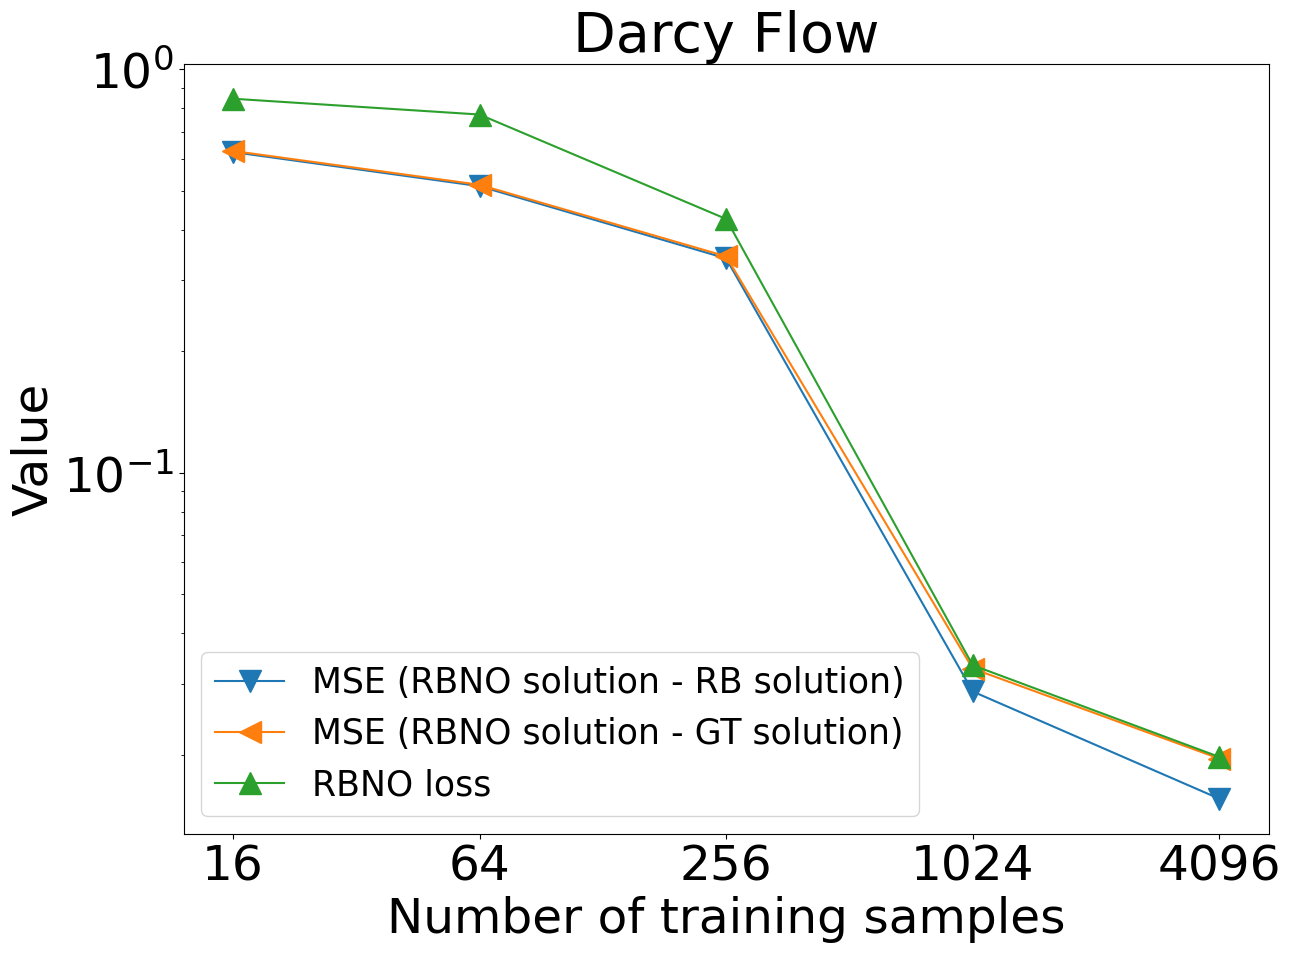

In [13]:
plt.figure(figsize=(14,10))
plt.plot(num_train_list, bochner_hdiv_h1_error_list, marker='v', markersize=16, label='MSE (RBNO solution - RB solution)')
plt.plot(num_train_list, finer_bochner_hdiv_h1_error_list, marker='<',  markersize=16, label='MSE (RBNO solution - GT solution)')
plt.plot(num_train_list, mean_residual_loss_list, marker='^', markersize=16, label='RBNO loss')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of training samples', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_train_list, num_train_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=25)
plt.title('Darcy Flow', fontsize=40)
plt.savefig(os.path.join(model_test_outputs_path , "mse_and_loss_vs_num_train.png"), dpi=300, bbox_inches='tight')
plt.show()